In [ ]:
!pip -q install duckdb pandas numpy pyarrow

In [ ]:
# librerias
import numpy as np
import pandas as pd
import duckdb
from datetime import datetime, timedelta

In [ ]:
# =========================
# 0) Config del generador
# =========================
SEED = 42
rng = np.random.default_rng(SEED)

START_DATE = pd.Timestamp("2023-02-01")
END_DATE   = pd.Timestamp("2025-01-01")

# Tamaños (portafolio demo)
N_CUSTOMERS = 1_000
N_ACCOUNTS  = 1_300
N_LOANS     = 1_100
N_TX        = 10_000

REGIONS  = ["Bogotá D.C.", "Antioquia", "Valle del Cauca", "Santander", "Atlántico", "Cundinamarca", "Bolívar"]
SEGMENTS = ["Mass", "Affluent", "SME"] # masivo, VIP, medianas y pequeñas empresas
PRODUCTS = ["Consumo", "Libranza", "Vehículo", "Tarjeta"]
TX_TYPES = ["POS", "Transfer", "ATM", "Online", "BillPay"]

# Creación de la tabla Customers (clientes)

1. "customer_id": La cual contiene el id único de cada cliente
2. "segment": El segmeneto de cada cliente, para esta simulaicón, se consideran tres:
    - "MASS": Publico general, es el segmegmento del publico en general.
    - "Affluent": Bancos o clientes VIP.
    - "SME": Compuesto por pequeññas y medianas empresas.
3. "age": Edad del cliente
4. "income": Ingreso mensual del cliente, el cual está relacionado con el segmenteo del cliente. Se supone que los ingresos siguen una distribución lognormal, es decir, muchos ganen poco y pocos ganen mucho.
5. "risk_score": Puntaje crediticio del cliente, el cual se simula asumiendo que el puntaje base es de 520 y a partir del salario y la edad se simula este puntaje.
6. "customer_since": Fecha desde la cual se tiene registro del cliente.

In [ ]:
# =========================
# 1) Customers (dim)  -> IDs ENTEROS
# =========================
customer_id = np.arange(1, N_CUSTOMERS + 1, dtype=np.int64)

segment = rng.choice(SEGMENTS, size=N_CUSTOMERS, p=[0.78, 0.12, 0.10])
region  = rng.choice(REGIONS, size=N_CUSTOMERS, p=[0.38, 0.13, 0.10, 0.09, 0.08, 0.12, 0.10])

age = np.clip(rng.normal(36, 12, size=N_CUSTOMERS).round().astype(int), 18, 75)

income = np.where(
    segment == "Mass",
    rng.lognormal(mean=np.log(500), sigma=0.45, size=N_CUSTOMERS),
    np.where(
        segment == "Affluent",
        rng.lognormal(mean=np.log(4000), sigma=0.55, size=N_CUSTOMERS),
        rng.lognormal(mean=np.log(1500), sigma=0.55, size=N_CUSTOMERS)
    )
).round().astype(np.int64)

base = 520 + 40*np.log1p(income/250) - 0.8*np.maximum(age-45, 0)
score = np.clip(base + rng.normal(0, 55, size=N_CUSTOMERS), 300, 850).round().astype(np.int16)

customers = pd.DataFrame({
    "customer_id": customer_id,
    "segment": segment,
    "region": region,
    "age": age.astype(np.int16),
    "income_monthly": income,
    "risk_score": score,
    "customer_since": (
        START_DATE + pd.to_timedelta(
            rng.integers(0, (END_DATE-START_DATE).days+1, size=N_CUSTOMERS),
            unit="D"
        )
    ).date
})


In [ ]:
customers.head()

,customer_id,segment,region,age,income_monthly,risk_score,customer_since
0,1,Mass,Bogotá D.C.,24,316,560,2024-11-18
1,2,Mass,Antioquia,47,635,519,2023-05-03
2,3,Affluent,Bogotá D.C.,22,6869,697,2024-12-22
3,4,Mass,Bogotá D.C.,33,543,487,2023-11-24
4,5,Mass,Santander,29,1203,659,2023-02-18


In [ ]:
customers.describe()

,customer_id,age,income_monthly,risk_score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,36.655000,1175.484000,576.574000
std,288.819436,11.313796,1535.449263,62.467501
min,1.000000,18.000000,134.000000,397.000000
25%,250.750000,28.000000,414.000000,535.000000
50%,500.500000,36.000000,597.500000,573.000000
75%,750.250000,44.000000,1038.500000,618.250000
max,1000.000000,73.000000,11957.000000,793.000000


# Creación de la tabla Accounts (cuentas)

En esta tabla se encuentran los productos asociados a cada cliente

1. "account_id": Id único de cada cuenta

2. "customer_id": Llave foranea de del id del cliente

3. "account_type": El tipo de cuenta, cuenta de ahorros: "Savings" o cuenta de debito: "Checking".

4. "opened_date": Fecha de apertura de la cuenta

5. "status": Estado de la cuenta, activa:"Active",  inactiva: "Dormant", cerrada: "Closed".

In [ ]:
# =========================
# 2) Accounts (dim/fact light) -> IDs ENTEROS
# =========================
account_id = np.arange(1, N_ACCOUNTS + 1, dtype=np.int64)
acc_customer = rng.choice(customer_id, size=N_ACCOUNTS, replace=True)

account_type = rng.choice(["Savings", "Checking"], size=N_ACCOUNTS, p=[0.65, 0.35])
opened_date = (
    START_DATE + pd.to_timedelta(
        rng.integers(0, (END_DATE-START_DATE).days+1, size=N_ACCOUNTS),
        unit="D"
    )
).date
status = rng.choice(["Active", "Dormant", "Closed"], size=N_ACCOUNTS, p=[0.82, 0.14, 0.04])

accounts = pd.DataFrame({
    "account_id": account_id,
    "customer_id": acc_customer.astype(np.int64),
    "account_type": account_type,
    "opened_date": opened_date,
    "status": status
})

In [ ]:
accounts.head()

,account_id,customer_id,account_type,opened_date,status
0,1,939,Savings,2024-12-04,Active
1,2,887,Savings,2023-07-08,Active
2,3,626,Savings,2024-01-27,Active
3,4,577,Savings,2024-09-01,Active
4,5,361,Savings,2024-12-25,Dormant


In [ ]:
accounts.describe()

,account_id,customer_id
count,1300.000000,1300.000000
mean,650.500000,511.189231
std,375.421985,289.458797
min,1.000000,2.000000
25%,325.750000,258.750000
50%,650.500000,519.500000
75%,975.250000,760.250000
max,1300.000000,1000.000000


# Creación de la tabla Loans (credito)

En esta tabla se encuentra todos los creditos del banco sobre sus clientes:

1.    "loan_id": Id único del credito.
2.  "customer_id": Id del cliente.
3. "product": tipo de credito, pueden ser "Consumo", "Libranza", "Hipotecario", "Vehículo"o "Tarjeta".

4. "origination_date": Fecha de inicio del credito.
5. "amount": Monto  del prestamo.
6. "term_months": plazo en meses
7. "interest_rate": tasa de interes
8. "pd_latent": Probabilidad de incumplimiento, este puntaje se simula a partir del puntaje crediticio ya simulado en la tabla Customers.

In [ ]:
# =========================
# 3) Loans (fact) -> IDs ENTEROS
# =========================
loan_id = np.arange(1, N_LOANS + 1, dtype=np.int64)
loan_customer = rng.choice(customer_id, size=N_LOANS, replace=True)

loan_product = rng.choice(PRODUCTS, size=N_LOANS, p=[ 0.30, 0.25, 0.20, 0.25])

origination_date = (
    START_DATE + pd.to_timedelta(
        rng.integers(0, (END_DATE-START_DATE).days+1, size=N_LOANS),
        unit="D"
    )
).date

def loan_amount(prod, rng_):
    if prod == "Vehículo":
        return rng_.lognormal(np.log(11_000), 0.55)
    if prod == "Libranza":
        return rng_.lognormal(np.log(4_500), 0.55)
    if prod == "Tarjeta":
        return rng_.lognormal(np.log(1_500), 0.65)
    return rng_.lognormal(np.log(3_000), 0.65)

amount = np.array([loan_amount(p, rng) for p in loan_product]).round().astype(np.int64)

term_months = np.where(loan_product=="Vehículo", 60,
    np.where(loan_product=="Libranza", 48,
    np.where(loan_product=="Tarjeta", 24, 36))).astype(np.int16)

cust_score_vec = customers["risk_score"].to_numpy()



idx_c = loan_customer.astype(int) - 1
loan_score = cust_score_vec[idx_c]



base_rate = np.select(
    [ loan_product=="Vehículo", loan_product=="Libranza", loan_product=="Tarjeta"],
    [ 0.18, 0.16, 0.28],
    default=0.22
)

interest_rate = base_rate + ((850 - loan_score)/550)*0.10 + rng.normal(0, 0.01, size=N_LOANS)
interest_rate = np.clip(interest_rate, 0.09, 0.45)

pd_latent = 0.01 + ((850 - loan_score)/550)*0.25
pd_latent = np.clip(pd_latent + rng.normal(0, 0.02, size=N_LOANS), 0.01, 0.40)

loans = pd.DataFrame({
    "loan_id": loan_id,
    "customer_id": loan_customer.astype(np.int64),
    "product": loan_product,
    "origination_date": origination_date,
    "amount": amount,
    "term_months": term_months,
    "interest_rate": interest_rate.round(4),
    "pd_latent": pd_latent.round(4)
})

In [ ]:
loans.head()

,loan_id,customer_id,product,origination_date,amount,term_months,interest_rate,pd_latent
0,1,210,Libranza,2023-02-01,5535,48,0.1934,0.0738
1,2,60,Vehículo,2023-05-26,10689,60,0.2400,0.1502
2,3,797,Tarjeta,2024-05-21,2561,24,0.3303,0.1728
3,4,728,Tarjeta,2023-06-09,2809,24,0.3454,0.1541
4,5,54,Vehículo,2023-04-17,9575,60,0.2277,0.1747


Ver si hay relación entre pd_latent e interest_rate

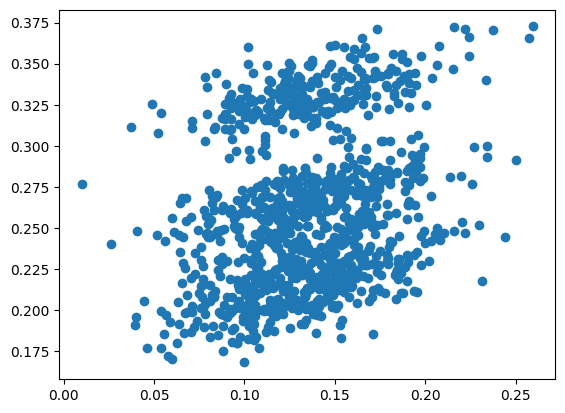

In [ ]:
import matplotlib.pyplot as plt

# Gráfico
fig, ax = plt.subplots()
ax.scatter(x = loans["pd_latent"], y = loans["interest_rate"])
plt.show()


# Cración de la tabla Payments (calendario de pagos)

En esta tabla se detalla el flujo de caja de cada crédito. Se asume un sistema de amortización francés (cuotas fijas) con pagos vencidos al final de cada mes:

1. "payment_id": Id único del pago
2.	"loan_id": Id foraneo del prestamos
3. "customer_id": Id foraneo del cliente
4.  "origination_date": Fecha inicio del credito
5.  "installment_n": número de la cuota
6.  amount_due: Monto de la cuota mensual a pagar (calculado con tasa mensual exacta).
7.	"due_date": Fecha de vencimiento
8.	"days_late": Días de retraso
9.  paid_date: Fecha real en la que el cliente realizó el pago (due_date + days_late).
10. paid_amount: Monto efectivamente pagado (para este ejercicio, se asume que siempre es el 100% de amount_due).

In [ ]:
# =========================
# 4) Payments schedule (fact) -> DINÁMICO POR PLAZO
# =========================

# 1. Repetir cada fila de 'loans' según su propio 'term_months'
# Esto crea la cantidad exacta de cuotas para cada crédito (24, 36, 48 o 60)
payments = loans[["loan_id", "customer_id", "origination_date", "amount", "interest_rate", "pd_latent", "term_months"]].copy()
payments = payments.loc[payments.index.repeat(payments["term_months"])].reset_index(drop=True)

# 2. Generar el número de cuota (1, 2, 3...) para cada grupo de préstamo
payments["installment_n"] = payments.groupby("loan_id").cumcount() + 1

# 3. Calcular la cuota mensual usando el Sistema de Amortización Francés (Cuota Fija)
# Fórmula: PMT = [P * r * (1+r)^n] / [(1+r)^n - 1]
# P = Principal, r = tasa mensual, n = número de meses

# CONVERSIÓN EXACTA DE TASA (De Efectiva Anual a Efectiva Mensual)
# Fórmula: (1 + EA)^(1/12) - 1
r = (1 + payments["interest_rate"])**(1/12) - 1
n = payments["term_months"]
P = payments["amount"]

payments["amount_due"] = (P * (r * (1 + r)**n) / ((1 + r)**n - 1)).round().astype(np.int64)

# 4. Calcular fechas de vencimiento (due_date)
# Cada cuota vence 30 días después de la anterior, partiendo de la fecha de origen
orig = pd.to_datetime(payments["origination_date"])
payments["due_date"] = (orig + pd.to_timedelta(30 * payments["installment_n"], unit="D")).dt.date
payments["paid_amount"] = payments["amount_due"]

# 5. Simular pagos y mora (manteniendo tu lógica de pd_latent)


u = rng.random(len(payments))
# Si u < pd_latent, el cliente se atrasa. El atraso es proporcional a su riesgo.
days_late = np.where(
    u < payments["pd_latent"],
    (1 + (payments["pd_latent"] * 60 + rng.random(len(payments)) * 20)).round().astype(int),
    0
).astype(np.int16)

payments["days_late"] = days_late

# 6. Fecha de pago real y monto pagado
paid_date = pd.to_datetime(payments["due_date"]) + pd.to_timedelta(days_late.astype(int), unit="D")
payments["paid_date"] = paid_date.dt.date


# 7. Crear ID único de pago y limpiar columnas sobrantes de la relación
payments.insert(0, "payment_id", np.arange(1, len(payments) + 1, dtype=np.int64))
payments = payments.drop(columns=["amount", "interest_rate", "pd_latent", "term_months"])

In [ ]:
payments.head()

,payment_id,loan_id,customer_id,origination_date,installment_n,amount_due,due_date,paid_amount,days_late,paid_date
0,1,1,210,2023-02-01,1,162,2023-03-03,162,0,2023-03-03
1,2,1,210,2023-02-01,2,162,2023-04-02,162,0,2023-04-02
2,3,1,210,2023-02-01,3,162,2023-05-02,162,17,2023-05-19
3,4,1,210,2023-02-01,4,162,2023-06-01,162,0,2023-06-01
4,5,1,210,2023-02-01,5,162,2023-07-01,162,0,2023-07-01


In [ ]:
payments.describe()

,payment_id,loan_id,customer_id,installment_n,amount_due,paid_amount,days_late
count,45336.000000,45336.000000,45336.000000,45336.000000,45336.000000,45336.000000,45336.000000
mean,22668.500000,548.108523,510.332980,23.057967,209.444150,209.444150,2.625419
std,13087.520239,316.509972,285.431446,14.833390,169.206478,169.206478,7.045509
min,1.000000,1.000000,1.000000,1.000000,9.000000,9.000000,0.000000
25%,11334.750000,273.000000,264.000000,11.000000,93.000000,93.000000,0.000000
50%,22668.500000,548.000000,507.000000,21.000000,159.000000,159.000000,0.000000
75%,34002.250000,822.000000,758.000000,33.000000,275.000000,275.000000,0.000000
max,45336.000000,1100.000000,1000.000000,60.000000,1121.000000,1121.000000,35.000000


A continuación se hace la verificación de que el valor presente de la amortización es el valor del prestamo, las diferencias númericas se deben al redondeo hecho en la simulación.

In [ ]:
# 1. Seleccionar un préstamo al azar
sample_loan = loans.sample(3).iloc[0]
l_id = sample_loan['loan_id']
monto_original = sample_loan['amount']
tasa_ea = sample_loan['interest_rate']

# 2. Obtener sus pagos de la tabla payments
cuotas_del_prestamo = payments[payments['loan_id'] == l_id].copy()

# 3. Calcular la tasa mensual exacta que usamos
r_m = (1 + tasa_ea)**(1/12) - 1

# 4. Traer cada cuota a valor presente
# Formula: VP_cuota = Cuota / (1 + r_m)^n
cuotas_del_prestamo['valor_presente_cuota'] = (
    cuotas_del_prestamo['amount_due'] / ((1 + r_m) ** cuotas_del_prestamo['installment_n'])
)

# 5. Sumar todos los valores presentes
suma_valor_presente = cuotas_del_prestamo['valor_presente_cuota'].sum()

# 6. Mostrar resultados
print(f"--- VERIFICACIÓN FINANCIERA (Loan ID: {l_id}) ---")
print(f"Monto Original:       {monto_original:,.2f}")
print(f"Suma Valor Presente:  {suma_valor_presente:,.2f}")
print(f"Diferencia:           {abs(monto_original - suma_valor_presente):,.2f}")
print(f"-----------------------------------------------")

--- VERIFICACIÓN FINANCIERA (Loan ID: 27) ---
Monto Original:       7,375.00
Suma Valor Presente:  7,367.29
Diferencia:           7.71
-----------------------------------------------


# Creación de la tabla Transactions:

Se crea la tabla con las transacciones de cada cliente

1.  "tx_id": Id único de cada transacción
2. "tx_date": Fecha de cada transacción
3. "customer_id": Id foraneo del cliente
4. "tx_type": Tipo de transación
5. "amount": Monto de la trasación, este monto está relacionado con el tipo de cliente.


In [ ]:
# =========================
# 6) Transactions (fact) -> BASADO EN SEGMENTOS
# =========================

# 1. Generar IDs y asignar clientes
tx_id = np.arange(1, N_TX + 1, dtype=np.int64)
tx_customer = rng.choice(customer_id, size=N_TX, replace=True)

# 2. Obtener el segmento de cada cliente asignado a la transacción
# (Usamos el índice para mapear rápido)
cust_segments_map = customers.set_index("customer_id")["segment"]
tx_segments = cust_segments_map.loc[tx_customer].values

# 3. Definir montos y tipos de transacción según el segmento
# Creamos una lista para llenar los montos
amount_tx = np.zeros(N_TX, dtype=np.int64)
tx_type = np.empty(N_TX, dtype=object)

for seg in SEGMENTS:
    idx = (tx_segments == seg)
    size = int(idx.sum())
    if size == 0: continue

    if seg == "Mass":
        # Compras pequeñas, mucho POS y ATM
        tx_type[idx] = rng.choice(TX_TYPES, size=size, p=[0.50, 0.10, 0.25, 0.10, 0.05])
        amount_tx[idx] = rng.integers(5, 150, size=size) # Montos bajos

    elif seg == "Affluent":
        # Compras más altas, mucho Online y POS
        tx_type[idx] = rng.choice(TX_TYPES, size=size, p=[0.40, 0.15, 0.05, 0.35, 0.05])
        amount_tx[idx] = rng.integers(50, 1200, size=size) # Montos altos

    elif seg == "SME":
        # Muchas transferencias y pagos de facturas (BillPay)
        tx_type[idx] = rng.choice(TX_TYPES, size=size, p=[0.15, 0.45, 0.05, 0.10, 0.25])
        amount_tx[idx] = rng.integers(200, 3500, size=size) # Montos de negocio

# 4. Generar fechas de transacciones
tx_date = (
    START_DATE + pd.to_timedelta(
        rng.integers(0, (END_DATE-START_DATE).days+1, size=N_TX),
        unit="D"
    )
).date

# 5. Crear el DataFrame final
transactions = pd.DataFrame({
    "tx_id": tx_id,
    "tx_date": tx_date,
    "customer_id": tx_customer.astype(np.int64),
    "segment": tx_segments, # Opcional: la dejamos para facilitar el análisis SQL después
    "tx_type": tx_type,
    "amount": amount_tx
})

In [ ]:
transactions.head()

,tx_id,tx_date,customer_id,segment,tx_type,amount
0,1,2024-11-07,107,Mass,BillPay,22
1,2,2024-09-16,367,Mass,ATM,126
2,3,2024-08-21,999,SME,Transfer,1603
3,4,2023-12-18,46,Affluent,POS,936
4,5,2023-02-25,88,Mass,ATM,49


Vemos una relación del tipo de cliente y las cantidades de las transacciones

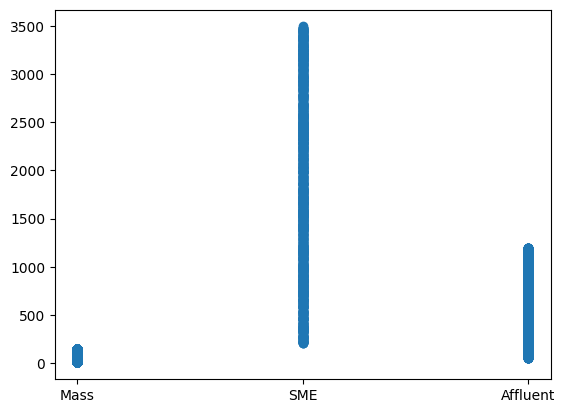

In [ ]:
import matplotlib.pyplot as plt
# Gráfico
fig, ax = plt.subplots()
ax.scatter(x = transactions["segment"], y = transactions["amount"])
plt.show()

In [ ]:
transactions = pd.DataFrame({
    "tx_id": tx_id,
    "tx_date": tx_date,
    "customer_id": tx_customer.astype(np.int64),
    #"segment": tx_segments, # Opcional: la dejamos para facilitar el análisis SQL después
    "tx_type": tx_type,
    "amount": amount_tx
})

# Diagrama de relación
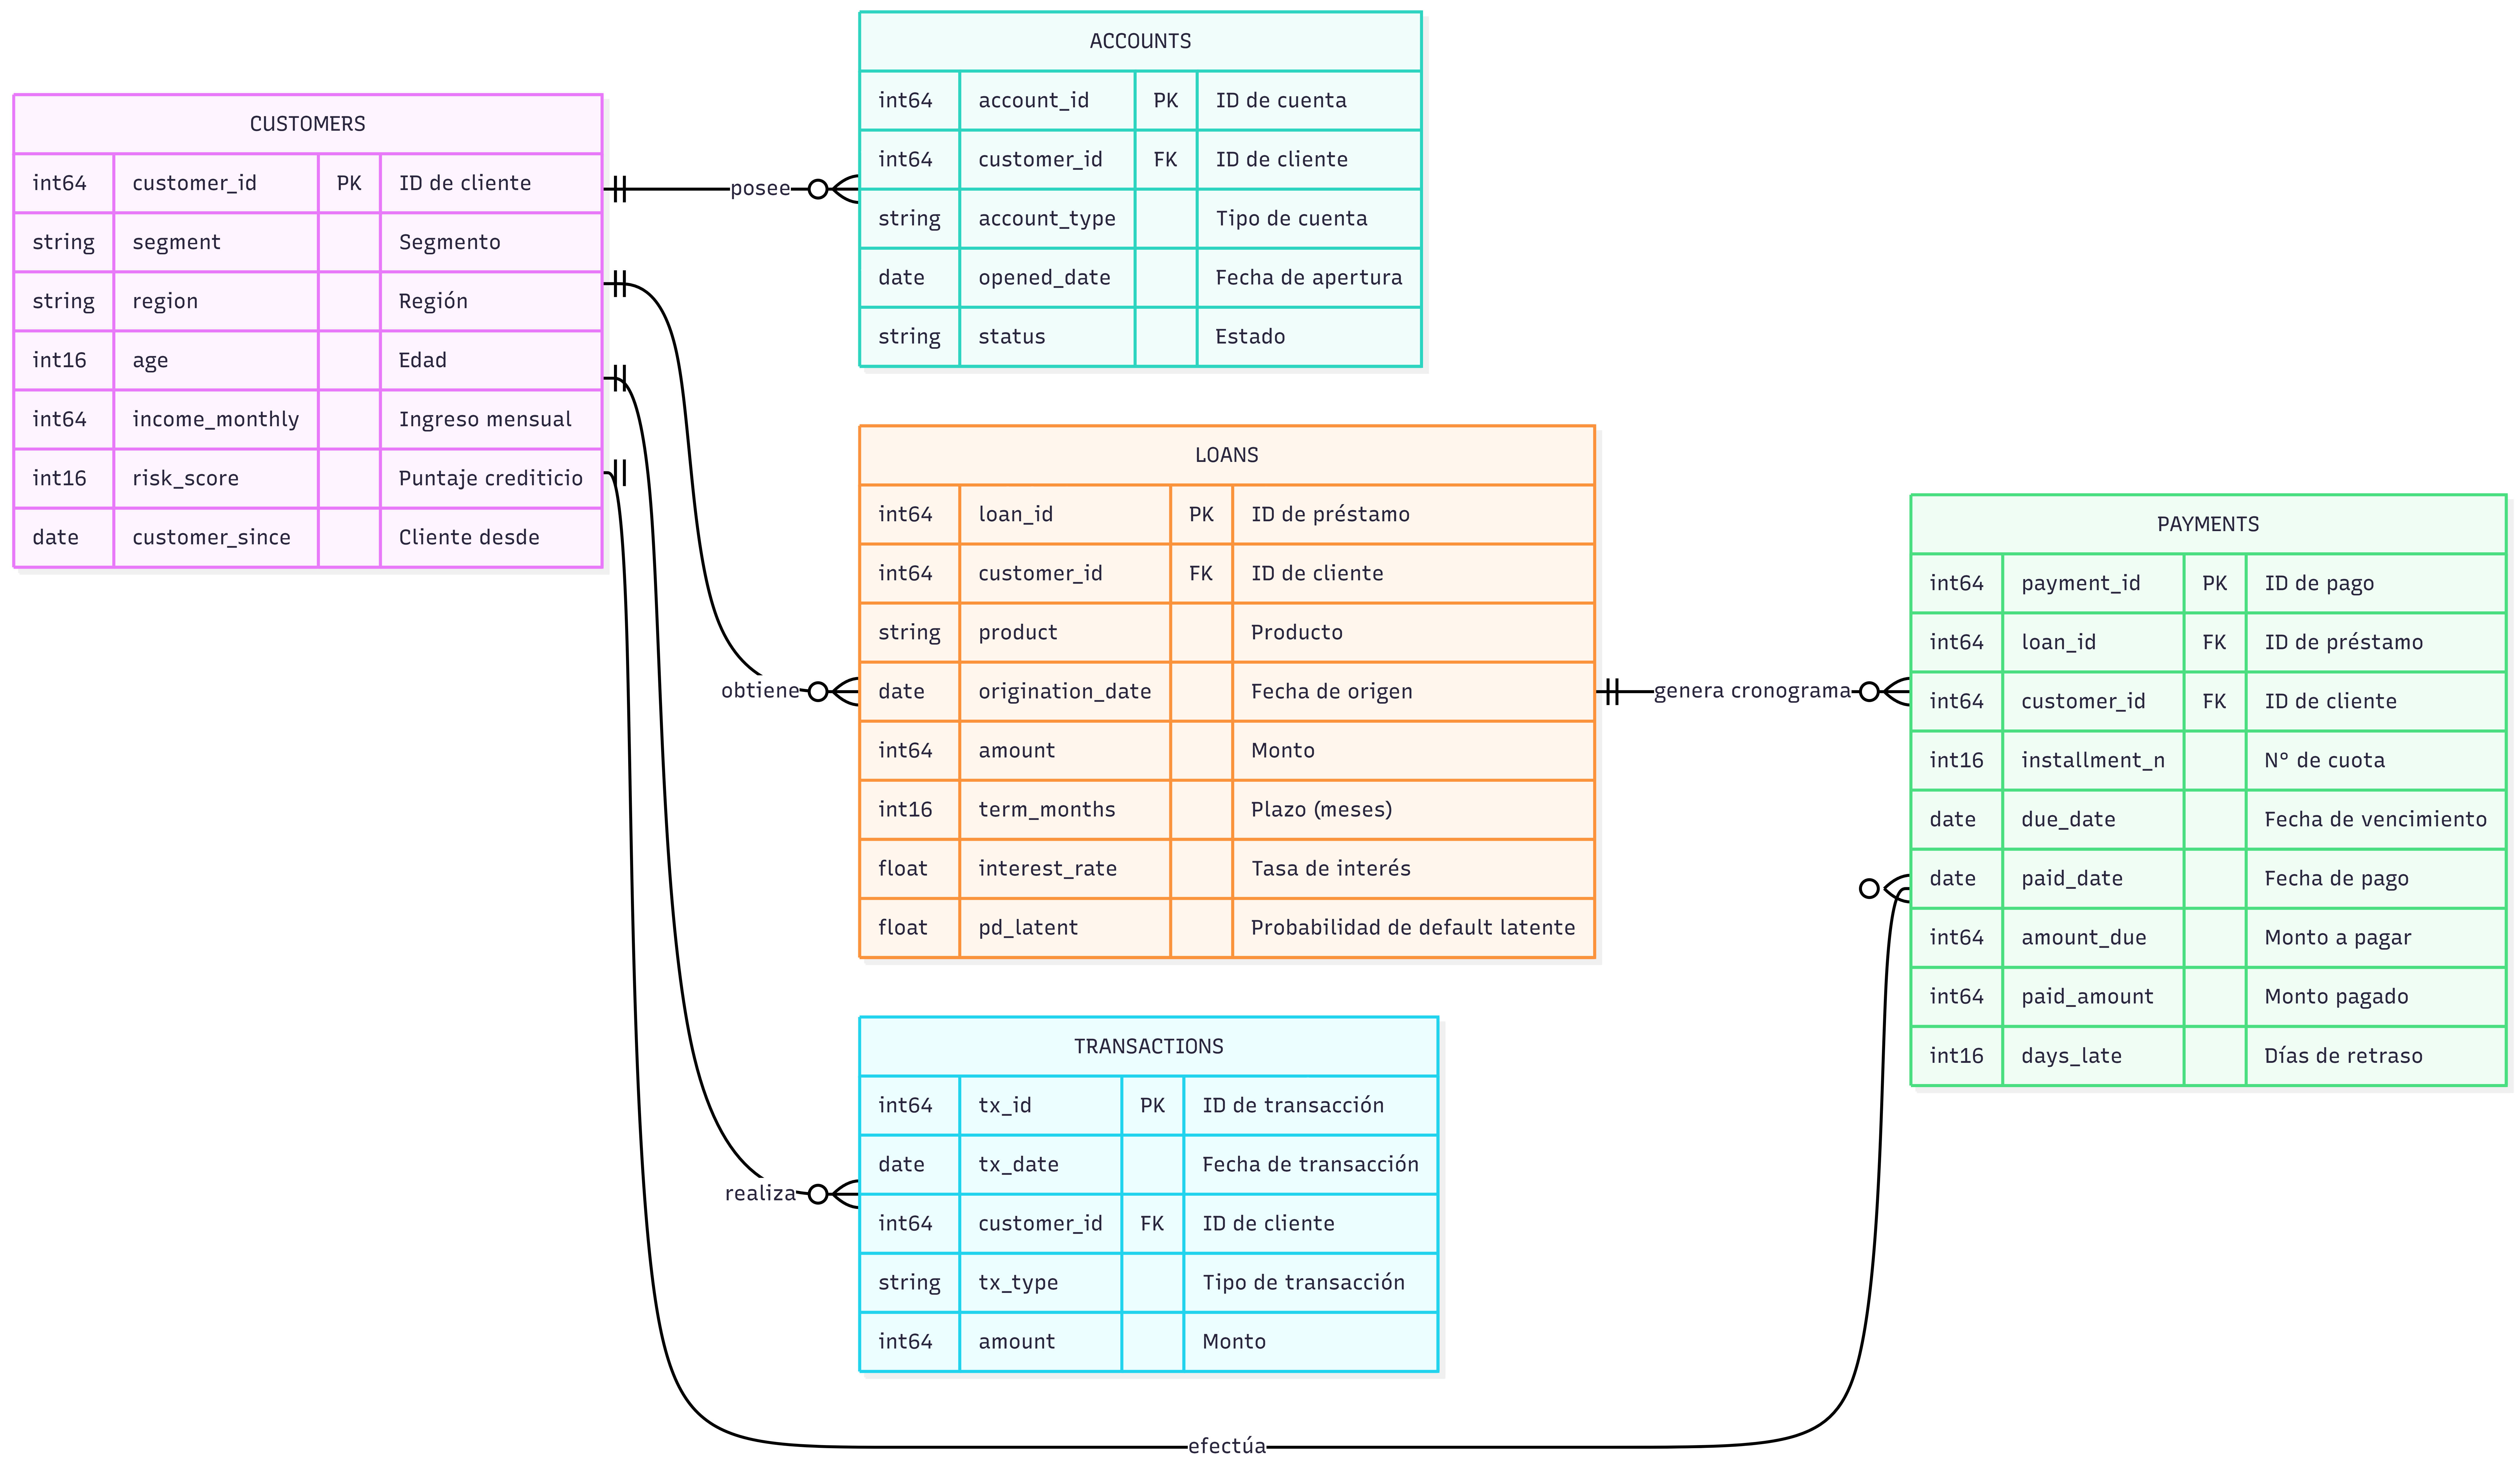

# Guardar las tablas

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")
def format_dates(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce").dt.strftime("%Y-%m-%d")
    return df

customers = format_dates(customers, ["customer_since"])
accounts = format_dates(accounts, ["opened_date"])
loans = format_dates(loans, ["origination_date"])
payments = format_dates(payments, ["origination_date","due_date","paid_date"])
transactions = format_dates(transactions, ["tx_date"])

from google.colab import files

customers.to_csv("/content/drive/MyDrive/Portafolio/proyecto_sql/data/customers.csv", index=False, encoding="utf-8-sig")
accounts.to_csv("/content/drive/MyDrive/Portafolio/proyecto_sql/data/accounts.csv", index=False, encoding="utf-8-sig")
loans.to_csv("/content/drive/MyDrive/Portafolio/proyecto_sql/data/loans.csv", index=False, encoding="utf-8-sig")
payments.to_csv("/content/drive/MyDrive/Portafolio/proyecto_sql/data/payments.csv", index=False, encoding="utf-8-sig")
transactions.to_csv("/content/drive/MyDrive/Portafolio/proyecto_sql/data/transactions.csv", index=False, encoding="utf-8-sig")


Mounted at /content/drive


# Generar el formato para SQL

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

!pip -q install duckdb

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import duckdb
import os

DATA_DIR = "/content/drive/MyDrive/Portafolio/proyecto_sql/data"
DB_PATH  = "/content/drive/MyDrive/Portafolio/proyecto_sql/banking_risk.duckdb"

# (Opcional) borrar y recrear desde cero
# if os.path.exists(DB_PATH):
#     os.remove(DB_PATH)

con = duckdb.connect(DB_PATH)

# Crear tablas desde CSV (DuckDB infiere tipos)
con.execute(f"""
CREATE OR REPLACE TABLE customers AS
SELECT * FROM read_csv_auto('{DATA_DIR}/customers.csv', header=True);
""")

con.execute(f"""
CREATE OR REPLACE TABLE accounts AS
SELECT * FROM read_csv_auto('{DATA_DIR}/accounts.csv', header=True);
""")

con.execute(f"""
CREATE OR REPLACE TABLE loans AS
SELECT * FROM read_csv_auto('{DATA_DIR}/loans.csv', header=True);
""")

con.execute(f"""
CREATE OR REPLACE TABLE payments AS
SELECT * FROM read_csv_auto('{DATA_DIR}/payments.csv', header=True);
""")


con.execute(f"""
CREATE OR REPLACE TABLE transactions AS
SELECT * FROM read_csv_auto('{DATA_DIR}/transactions.csv', header=True);
""")

# (Recomendado) índices no existen como en MySQL, pero puedes crear vistas, etc.
con.close()

print("✅ Base creada en:", DB_PATH)

✅ Base creada en: /content/drive/MyDrive/Portafolio/proyecto_sql/banking_risk.duckdb
